In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


# Initialization

In [22]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

In [23]:
!pip install -q mlflow dagshub

In [6]:
PATH = "/kaggle/input/competitions/ieee-fraud-detection/"

In [24]:
import mlflow
import dagshub

dagshub.init(repo_owner='ZukaCS', repo_name='ML_assignment_2', mlflow=True)

Initialized MLflow to track repo "ZukaCS/ML_assignment_2"

Repository ZukaCS/ML_assignment_2 initialized!

In [26]:
import mlflow
import mlflow.sklearn
import gc
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin


EXPERIMENT_NAME = "LogisticRegression_Training_v1.1"
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME)

2026/05/06 13:44:26 INFO mlflow.tracking.fluent: Experiment with name 'LogisticRegression_Training_v1.1' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow
Experiment: LogisticRegression_Training_v1.1


In [27]:
PATH = "/kaggle/input/competitions/ieee-fraud-detection/"

train_tx = pd.read_csv(PATH + "train_transaction.csv")
train_id = pd.read_csv(PATH + "train_identity.csv")

train = train_tx.merge(train_id, on="TransactionID", how="left")
del train_tx, train_id; gc.collect()

print(f"Train shape: {train.shape}")
print(f"Fraud rate: {train['isFraud'].mean():.4f}")

Train shape: (590540, 434)
Fraud rate: 0.0350


In [28]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [29]:
y = train['isFraud']
X = train.drop(columns=['isFraud']) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Train fraud rate: {y_train.mean():.4f}")
print(f"test fraud rate:   {y_test.mean():.4f}")



Train: 472,432 rows | Test: 118,108 rows
Train fraud rate: 0.0350
test fraud rate:   0.0350


# Data cleaning / preprocessing


In [30]:
class UselessColumnRemover(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop=None):
        self.cols_to_drop = cols_to_drop if cols_to_drop is not None else ['TransactionID']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns],
                      errors='ignore').copy()


In [31]:
class MissingValueHandler(BaseEstimator, TransformerMixin):

    def __init__(self, missing_threshold=0.75):
        self.missing_threshold = missing_threshold
        self.cols_to_drop_ = None
        self.cols_to_flag_ = None

    def fit(self, X, y=None):
        missing_rate = X.isnull().mean()
        self.cols_to_drop_ = missing_rate[missing_rate > self.missing_threshold].index.tolist()
        self.cols_to_flag_ = missing_rate[
            (missing_rate > 0.25) & (missing_rate <= self.missing_threshold)
        ].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols_to_flag_:
            if col in X.columns:
                X[col + '_missing'] = X[col].isnull().astype(np.int8)
        X = X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])
        return X

In [33]:
with mlflow.start_run(run_name="LR_Cleaning_Preprocessing"):
    remover = UselessColumnRemover(cols_to_drop=['TransactionID'])
    cleaner = MissingValueHandler(missing_threshold=0.75)
    
    X_train_clean = remover.fit_transform(X_train)
    X_train_clean = cleaner.fit_transform(X_train_clean)
    X_test_clean = remover.transform(X_test)
    X_test_clean = cleaner.transform(X_test_clean)

    mlflow.log_param("dropped_useless_cols", str(remover.cols_to_drop))
    mlflow.log_param("missing_threshold", 0.75)
    mlflow.log_param("mark_missing_interval", "(0.25 to 0.75]")
    mlflow.log_metric("missing_marks_added",  len(cleaner.cols_to_flag_))
    mlflow.log_metric("dropped_missing_cols_count", len(cleaner.cols_to_drop_))
    mlflow.log_metric("remaining_cols_count",       X_train_clean.shape[1])

    print(f"dropped useless cols: {remover.cols_to_drop}")
    print(f"missing marks/ added: {len(cleaner.cols_to_flag_)} cols")
    print(f"Dropped missing cols cnt: {len(cleaner.cols_to_drop_)} cols")
    print(f"Remaining columns cnt: {X_train_clean.shape[1]} cols")

dropped useless cols: ['TransactionID']
missing marks/ added: 44 cols
Dropped missing cols cnt: 208 cols
Remaining columns cnt: 268 cols
🏃 View run LR_Cleaning_Preprocessing at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1/runs/16e54e03cee843ecb509a9b98274d398
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1


# Feature engineering 

In [38]:
class FeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, verbose=True):
        self.user_stats_ = None
        self.verbose = verbose

    def _log(self, msg):
        if self.verbose:
            print(msg)

    def fit(self, X, y=None):
        X = X.copy()
        if 'card1' in X.columns and 'TransactionAmt' in X.columns:
            X['_user_id'] = self._make_user_id(X)
            self.user_stats_ = (
                X.groupby('_user_id')['TransactionAmt']
                 .agg(['count', 'mean', 'std'])
                 .rename(columns={'count': 'user_tr_count',
                                  'mean':  'user_amt_mean',
                                  'std':   'user_amt_standart_dev'})
            )
            self._log(f"Fitted user_stats on {len(self.user_stats_):,} unique users")
        else:
            self._log("Skipping user_stats fit — card1 or TransactionAmt missing")
        return self

    def transform(self, X):
        X = X.copy()
        skipped = []
        added = []

        if 'TransactionAmt' in X.columns:
            X['TransactionAmt_logarithm']   = np.log1p(X['TransactionAmt'])
            X['TransactionAmt_cents'] = X['TransactionAmt'] % 1
            added += ['TransactionAmt_logarithm', 'TransactionAmt_cents']
        else:
            skipped += ['TransactionAmt_logarithm', 'TransactionAmt_cents']

        if 'P_emaildomain' in X.columns and 'R_emaildomain' in X.columns:
            X['email_match'] = (X['P_emaildomain'] == X['R_emaildomain']).astype(np.int8)
            added += ['email_match']
        else:
            skipped += ['email_match']

        if 'TransactionDT' in X.columns:
            X['hour_of_transaction'] = (X['TransactionDT'] // 3600) % 24
            X['day_of_transaction']  = (X['TransactionDT'] // (3600 * 24)) % 7
            added += ['hour_of_transaction', 'day_of_transaction']
        else:
            skipped += ['hour_of_transaction', 'day_of_transaction']

        if 'card1' in X.columns and 'TransactionAmt' in X.columns and self.user_stats_ is not None:
            X['_user_id'] = self._make_user_id(X)
            X = X.join(self.user_stats_, on='_user_id')
            X['user_amt_standart_dev']  = X['user_amt_standart_dev'].fillna(0)
            X['user_amt_zscore'] = (
                (X['TransactionAmt'] - X['user_amt_mean']) /
                X['user_amt_standart_dev'].replace(0, 1)
            ).clip(-5, 5)
            X['user_tr_count_logarithm'] = np.log1p(X['user_tr_count'])
            X = X.drop(columns=['_user_id'])
            added += ['user_tr_count', 'user_amt_mean', 'user_amt_standart_dev',
                      'user_amt_zscore', 'user_tr_count_logarithm']
        else:
            skipped += ['user_tr_count', 'user_amt_mean', 'user_amt_standart_dev',
                        'user_amt_zscore', 'user_tr_count_logarithm']

        self._log(f"Added {len(added)} features: {added}")
        if skipped:
            self._log(f"Skipped {len(skipped)} features (missing source cols): {skipped}")

        return X

    @staticmethod
    def _make_user_id(X):
        return (
            X['card1'].fillna(-1).astype(str) + '_' +
            X.get('card2', pd.Series(-1, index=X.index)).fillna(-1).astype(str) + '_' +
            X.get('addr1', pd.Series(-1, index=X.index)).fillna(-1).astype(str) + '_' +
            X.get('P_emaildomain', pd.Series('unknown', index=X.index)).fillna('unknown').astype(str)
        )

In [39]:
with mlflow.start_run(run_name="LR_Feature_Engineering"):
    fe = FeatureAdder()
    fe.fit(X_train_clean)
    X_train_fe = fe.transform(X_train_clean)
    X_test_fe  = fe.transform(X_test_clean)   
    
    mlflow.log_param("user_id_components", "card1_card2_addr1_P_emaildomain")
    mlflow.log_param("features_added", "log_amt, cents, hour, day, user_aggs (email_match dropped)")
    mlflow.log_metric("n_features_after_FeatureEng", X_train_fe.shape[1])
    print(f"Features after FE: {X_train_fe.shape[1]}")

Fitted user_stats on 82,988 unique users
Added 9 features: ['TransactionAmt_logarithm', 'TransactionAmt_cents', 'hour_of_transaction', 'day_of_transaction', 'user_tr_count', 'user_amt_mean', 'user_amt_standart_dev', 'user_amt_zscore', 'user_tr_count_logarithm']
Skipped 1 features (missing source cols): ['email_match']
Added 9 features: ['TransactionAmt_logarithm', 'TransactionAmt_cents', 'hour_of_transaction', 'day_of_transaction', 'user_tr_count', 'user_amt_mean', 'user_amt_standart_dev', 'user_amt_zscore', 'user_tr_count_logarithm']
Skipped 1 features (missing source cols): ['email_match']
Features after FE: 277
🏃 View run LR_Feature_Engineering at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1/runs/db7dfa1154c04febae0b4ebaed0435cf
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1


In [40]:
from sklearn.preprocessing import LabelEncoder

class MyCategoricalEncoder(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.encoders_ = {}
        self.cat_cols_ = None

    def fit(self, X, y=None):
        self.cat_cols_ = X.select_dtypes(include=['object']).columns.tolist()
        for col in self.cat_cols_:
            le = LabelEncoder()
            vals = X[col].fillna('missing').astype(str)
            classes = list(np.unique(vals))
            if 'missing' not in classes:
                classes.append('missing')
            le.classes_ = np.array(sorted(classes))
            self.encoders_[col] = le
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cat_cols_:
            if col in X.columns:
                vals = X[col].fillna('missing').astype(str)
                known = set(self.encoders_[col].classes_)
                vals = vals.apply(lambda v: v if v in known else 'missing')
                X[col] = self.encoders_[col].transform(vals)
        return X



In [41]:
with mlflow.start_run(run_name="LR_Categorical_Encoding"):
    encoder = MyCategoricalEncoder()
    encoder.fit(X_train_fe)
    X_train_enc = encoder.transform(X_train_fe)
    X_test_enc  = encoder.transform(X_test_fe)

    mlflow.log_param("encoding_method", "label_encoding")
    mlflow.log_param("NAN_placeholder", "missing")
    mlflow.log_param("unseen_strategy", "map_to_missing")
    mlflow.log_metric("categorical_cols_count", len(encoder.cat_cols_))
    mlflow.log_metric("features_after_encoding_count", X_train_enc.shape[1])
    mlflow.log_metric("NAN_count_remaining", int(X_train_enc.isnull().sum().sum()))

    print(f"Categorical columns encoded: {len(encoder.cat_cols_)}")
    print(f"Shape after encoding: {X_train_enc.shape}")
    print(f"Object cols left : {len(X_train_enc.select_dtypes(include=['object']).columns)}")
    print(f"total NaN count: {X_train_enc.isnull().sum().sum()}")

Categorical columns encoded: 13
Shape after encoding: (472432, 277)
Object cols left : 0
total NaN count: 10681614
🏃 View run LR_Categorical_Encoding at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1/runs/4bf8e201e5e841b68e1e9d4d5b9f1f11
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1


In [42]:
with mlflow.start_run(run_name="LR_Imputation"):
    imputer_for_selection = SimpleImputer(strategy='median')
    
    X_train_imp = pd.DataFrame(
        imputer_for_selection.fit_transform(X_train_enc),
        columns=X_train_enc.columns,
        index=X_train_enc.index,
    )
    X_test_imp = pd.DataFrame(
        imputer_for_selection.transform(X_test_enc),
        columns=X_test_enc.columns,
        index=X_test_enc.index,
    )
    
    mlflow.log_param("imputer_strategy", "median")
    mlflow.log_metric("n_features",         X_train_imp.shape[1])
    mlflow.log_metric("nan_count_before",   int(X_train_enc.isnull().sum().sum()))
    mlflow.log_metric("nan_count_after",    int(X_train_imp.isnull().sum().sum()))
    
    print(f"Imputed: {X_train_enc.isnull().sum().sum():,} NaNs → 0")

Imputed: 10,681,614 NaNs → 0
🏃 View run LR_Imputation at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1/runs/96118acd351540db8dfcafa84be63175
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1


In [44]:
def LR_short_test(X_tr, y_tr, X_va, y_va):
    sc = StandardScaler()
    X_tr_p = sc.fit_transform(X_tr)
    X_va_p = sc.transform(X_va)
    
    model = LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        C=1.0,
        max_iter=200,
        random_state=42,
    )
    model.fit(X_tr_p, y_tr)
    train_auc = roc_auc_score(y_tr, model.predict_proba(X_tr_p)[:, 1])
    val_auc   = roc_auc_score(y_va, model.predict_proba(X_va_p)[:, 1])
    return train_auc, val_auc


# Feature Selection


In [47]:
class CorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.9, sample_size=50_000, random_state=42):
        self.threshold = threshold
        self.sample_size = sample_size
        self.random_state = random_state
        self.features_to_drop_ = None
        self.selected_features_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)

        if self.sample_size and len(X) > self.sample_size:
            X_sample = X.sample(self.sample_size, random_state=self.random_state)
        else:
            X_sample = X

        corr_matrix = X_sample.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        self.features_to_drop_ = set()
        for col in upper.columns:
            if any(upper[col] > self.threshold):

                partners = upper.index[upper[col] > self.threshold].tolist()
                for partner in partners:
                    if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                        self.features_to_drop_.add(col)
                    else:
                        self.features_to_drop_.add(partner)

        self.selected_features_ = [c for c in X.columns if c not in self.features_to_drop_]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X[self.selected_features_]




In [48]:
from joblib import Parallel, delayed
class IVSelector(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.02, sample_size=50_000, random_state=42, n_jobs=-1):
        self.threshold = threshold
        self.sample_size = sample_size
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.iv_scores_ = {}
        self.selected_features_ = None

    def _compute_iv(self, X, y, col):

        series = X[col].copy()

        if series.nunique() > 10:
            series = pd.qcut(series, q=10, duplicates='drop')

        df = pd.DataFrame({'col': series, 'target': y})
        total_event     = y.sum()
        total_non_event = (1 - y).sum()

        grp = df.groupby('col', observed=True)['target'].agg(['sum', 'count'])
        grp.columns = ['event', 'cnt']
        grp['non_event'] = grp['cnt'] - grp['event']

        dist_event     = (grp['event']     + 0.5) / (total_event     + 0.5)
        dist_non_event = (grp['non_event'] + 0.5) / (total_non_event + 0.5)

        return ((dist_event - dist_non_event) * np.log(dist_event / dist_non_event)).sum()

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        if self.sample_size and len(X) > self.sample_size:
            idx = y.sample(self.sample_size, random_state=self.random_state).index
            X_sample = X.loc[idx].reset_index(drop=True)
            y_sample = y.loc[idx].reset_index(drop=True)
        else:
            X_sample, y_sample = X, y

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._compute_iv)(X_sample, y_sample, col)
            for col in X_sample.columns
        )
        self.iv_scores_ = dict(zip(X_sample.columns, results))
        self.selected_features_ = [c for c, iv in self.iv_scores_.items() if iv >= self.threshold]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X[self.selected_features_]

## Logging filters

In [50]:
with mlflow.start_run(run_name="LR_With_only_CorrFilter"):
    corr_only = CorrelationFilter(threshold=0.9)
    corr_only.fit(X_train_imp)
    X_tr_corr = corr_only.transform(X_train_imp)
    X_te_corr = corr_only.transform(X_test_imp)
    
    train_auc, val_auc = LR_short_test(X_tr_corr, y_train, X_te_corr, y_test)
    
    mlflow.log_param("method", "pearson_correlation_only")
    mlflow.log_param("correlation_threshold", 0.9)
    mlflow.log_metric("n_features_before",  X_train_imp.shape[1])
    mlflow.log_metric("n_features_after",   X_tr_corr.shape[1])
    mlflow.log_metric("n_features_dropped", len(corr_only.features_to_drop_))
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc",   val_auc)
    mlflow.log_metric("auc_gap",   train_auc - val_auc)
    
    print(f"Corr only: {X_train_imp.shape[1]} → {X_tr_corr.shape[1]} features "
          f"(dropped {len(corr_only.features_to_drop_)}) | "
          f"train={train_auc:.4f} | val={val_auc:.4f}")



Corr only: 277 → 148 features (dropped 129) | train=0.8328 | val=0.8296
🏃 View run LR_With_only_CorrFilter at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1/runs/eaaa6796b20c45ef8fd7b90193041c78
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1


In [51]:
with mlflow.start_run(run_name="LR_With_IV_Corr_Filters"):
    iv = IVSelector(threshold=0.02)
    corr = CorrelationFilter(threshold=0.9)
    
    iv.fit(X_train_imp, y_train)
    X_tr_iv = iv.transform(X_train_imp)
    X_te_iv = iv.transform(X_test_imp)
    
    corr.fit(X_tr_iv)
    X_train_sel = corr.transform(X_tr_iv)
    X_test_sel  = corr.transform(X_te_iv)
    
    train_auc, val_auc = LR_short_test(X_train_sel, y_train, X_test_sel, y_test)
    
    mlflow.log_param("method", "iv_then_correlation")
    mlflow.log_param("iv_threshold", 0.02)
    mlflow.log_param("correlation_threshold", 0.9)
    mlflow.log_metric("n_features_before",     X_train_imp.shape[1])
    mlflow.log_metric("n_features_after_iv",   X_tr_iv.shape[1])
    mlflow.log_metric("n_features_final",      X_train_sel.shape[1])
    mlflow.log_metric("n_dropped_iv",          X_train_imp.shape[1] - X_tr_iv.shape[1])
    mlflow.log_metric("n_dropped_correlation", len(corr.features_to_drop_))
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc",   val_auc)
    mlflow.log_metric("auc_gap",   train_auc - val_auc)
    
    print(f"IV + Corr: {X_train_imp.shape[1]} → {X_tr_iv.shape[1]} → {X_train_sel.shape[1]} features | "
          f"train={train_auc:.4f} | val={val_auc:.4f}")


print(f"\nFinal selected for GridSearch: {X_train_sel.shape[1]} features (IV + Correlation)")

IV + Corr: 277 → 192 → 106 features | train=0.8298 | val=0.8291
🏃 View run LR_With_IV_Corr_Filters at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1/runs/680f976d1acf4dbf85894935a8b8415a
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1

Final selected for GridSearch: 106 features (IV + Correlation)


In [52]:
X_train_sel

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,dist1,P_emaildomain,C5,C13,C14,D2,D3,D4,D5,D10,D11,D15,M3,M4,M5,M6,M9,V5,V11,V12,V20,V22,V23,V24,V30,V34,V35,V37,V38,V40,V43,V44,V46,V47,V49,V52,V53,V55,V56,V61,V62,V64,V66,V67,V74,V75,V77,V78,V81,V82,V83,V85,V86,V87,V93,V95,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V119,V123,V124,V125,V130,V282,V283,V284,V288,V289,V291,V294,V303,V310,V312,V313,V314,dist1_missing,D2_missing,D3_missing,D11_missing,M6_missing,TransactionAmt_logarithm,TransactionAmt_cents,hour_of_transaction,user_tr_count,user_amt_mean,user_amt_standart_dev,user_amt_zscore,user_tr_count_logarithm
40809,1008491.0,100.000,2.0,6177.0,399.0,150.0,0.0,150.0,1.0,264.0,8.0,1.0,0.0,2.0,1.0,609.0,8.0,26.0,10.0,15.0,43.0,52.0,2.0,3.0,2.0,2.0,2.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,4.615121,0.000,16.0,2.0,100.000000,0.000000,0.000000,1.098612
285886,7008212.0,29.990,4.0,7900.0,345.0,150.0,2.0,224.0,2.0,143.0,4.0,16.0,0.0,0.0,0.0,97.0,8.0,0.0,10.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.433665,0.990,2.0,57.0,98.248772,69.418645,-0.983292,4.060443
104256,2071522.0,107.950,4.0,11690.0,111.0,150.0,4.0,226.0,1.0,191.0,8.0,9.0,1.0,15.0,1.0,501.0,18.0,502.0,18.0,502.0,43.0,502.0,2.0,3.0,2.0,1.0,2.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,200.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,200.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.690889,0.950,23.0,11.0,146.050000,63.803366,-0.597147,2.484907
507860,13299752.0,241.950,4.0,2616.0,327.0,150.0,1.0,102.0,1.0,330.0,3.0,31.0,1.0,4.0,1.0,177.0,86.0,26.0,10.0,177.0,177.0,177.0,0.0,3.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.492856,0.950,22.0,130.0,85.065615,118.654363,1.322197,4.875197
196382,4412283.0,117.000,4.0,13780.0,298.0,150.0,4.0,226.0,2.0,441.0,5.0,31.0,0.0,2.0,1.0,0.0,0.0,26.0,10.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,117.0,2.0,2.0,1.0,1.0,1.0,1.0,0.0,0.0,117.0,117.0,117.0,117.0,0.0,0.0,0.0,0.0,0.0,4.770685,0.000,1.0,232.0,67.614353,69.758134,0.707955,5.451038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324259,8019613.0,59.000,4.0,10493.0,455.0,150.0,2.0,126.0,2.0,123.0,8.0,16.0,0.0,5.0,2.0,311.0,289.0,289.0,289.0,308.0,43.0,311.0,2.0,0.0,1.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0,1.0,1.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.094345,0.

# Training

## Cross validation

In [58]:
from sklearn.model_selection import cross_validate

print("Running 5-fold CV. LR config (C=1.0, l2)...")

sanity_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        C=1.0,
        penalty='l2',
        solver='liblinear',
        class_weight='balanced',
        max_iter=200,
        random_state=42,
    )),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'auc':       'roc_auc',
    'f1':        'f1',
    'precision': 'precision',
    'recall':    'recall',
}

cv_out = cross_validate(
    sanity_pipe, X_train_sel, y_train,
    cv=skf, scoring=scoring,
    return_train_score=True, n_jobs=-1,
)

cv_train_auc = cv_out['train_auc'].mean()
cv_val_auc   = cv_out['test_auc'].mean()
cv_val_std   = cv_out['test_auc'].std()
cv_f1        = cv_out['test_f1'].mean()
cv_precision = cv_out['test_precision'].mean()
cv_recall    = cv_out['test_recall'].mean()

print(f"\nCV  check results (5 folds):")
print(f"  Train AUC:    {cv_train_auc:.4f}")
print(f"  Val AUC:      {cv_val_auc:.4f} ± {cv_val_std:.4f}")
print(f"  Val F1:       {cv_f1:.4f}")
print(f"  Val Precision:{cv_precision:.4f}")
print(f"  Val Recall:   {cv_recall:.4f}")



with mlflow.start_run(run_name="LR_CV_check"):
    mlflow.log_param("C", 1.0)
    mlflow.log_param("penalty", "l2")
    mlflow.log_param("cv_folds", 5)
    mlflow.set_tag("note", "CV check before hyperparam tuning")

    mlflow.log_metric("cv_train_auc", cv_train_auc)
    mlflow.log_metric("cv_val_auc",   cv_val_auc)
    mlflow.log_metric("cv_val_std",   cv_val_std)
    mlflow.log_metric("cv_auc_diff",  cv_train_auc - cv_val_auc)
    mlflow.log_metric("cv_f1",        cv_f1)
    mlflow.log_metric("cv_precision", cv_precision)
    mlflow.log_metric("cv_recall",    cv_recall)

    print("Logged CV check")

Running 5-fold CV. LR config (C=1.0, l2)...

CV  check results (5 folds):
  Train AUC:    0.8299
  Val AUC:      0.8283 ± 0.0031
  Val F1:       0.1764
  Val Precision:0.1002
  Val Recall:   0.7390
Logged CV check
🏃 View run LR_CV_check at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1/runs/1c842d7f365e47c29e36b84040913e59
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1


## Hyperparameter tuning and logging top 3 best and worst models

In [59]:
from sklearn.metrics import f1_score, precision_score, recall_score

configs = []
for C in [0.0001, 0.01, 0.1, 1.0, 10.0, 100.0, 10000.0]:
    for penalty in ['l1', 'l2']:
        configs.append({'C': C, 'penalty': penalty})

print(f"Will train {len(configs)} configs\n")



all_results = []

for i, cfg in enumerate(configs, 1):
    name = f"C{cfg['C']}_{cfg['penalty']}"
    print(f"[{i}/{len(configs)}] Training {name}...")
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(
            C=cfg['C'],
            penalty=cfg['penalty'],
            solver='liblinear',
            class_weight='balanced',
            max_iter=200,
            random_state=42,
        )),
    ])
    pipe.fit(X_train_sel, y_train)

    train_pred  = pipe.predict(X_train_sel)
    train_proba = pipe.predict_proba(X_train_sel)[:, 1]
    
    test_pred  = pipe.predict(X_test_sel)
    test_proba = pipe.predict_proba(X_test_sel)[:, 1]

    result = {
        'name':            name,
        'C':               cfg['C'],
        'penalty':         cfg['penalty'],
        'train_auc':       roc_auc_score(y_train, train_proba),
        'test_auc':        roc_auc_score(y_test,  test_proba),
        'train_f1':        f1_score(y_train, train_pred),
        'test_f1':         f1_score(y_test,  test_pred),
        'train_precision': precision_score(y_train, train_pred, zero_division=0),
        'test_precision':  precision_score(y_test,  test_pred,  zero_division=0),
        'train_recall':    recall_score(y_train, train_pred),
        'test_recall':     recall_score(y_test,  test_pred),
    }
    result['auc_diff'] = result['train_auc'] - result['test_auc']
    
    all_results.append(result)
    print(f"train AUC: {result['train_auc']:.4f}  |  test AUC: {result['test_auc']:.4f}  |  diff: {result['auc_diff']:+.4f}")


all_results = sorted(all_results, key=lambda r: r['test_auc'], reverse=True)

print("\n=== All configs sorted by test AUC ===")
for r in all_results:
    print(f"{r['name']:<22} | test AUC: {r['test_auc']:.4f} | diff: {r['auc_diff']:+.4f}")


def log_run(result, tag):
    with mlflow.start_run(run_name=f"LR_HP_{tag}_{result['name']}"):
        mlflow.set_tag("rank", tag)
        mlflow.log_param("C", result['C'])
        mlflow.log_param("penalty", result['penalty'])
        
        mlflow.log_metric("train_auc",       result['train_auc'])
        mlflow.log_metric("test_auc",        result['test_auc'])
        mlflow.log_metric("auc_diff",        result['auc_diff'])
        mlflow.log_metric("train_f1",        result['train_f1'])
        mlflow.log_metric("test_f1",         result['test_f1'])
        mlflow.log_metric("train_precision", result['train_precision'])
        mlflow.log_metric("test_precision",  result['test_precision'])
        mlflow.log_metric("train_recall",    result['train_recall'])
        mlflow.log_metric("test_recall",     result['test_recall'])


print("\nLoggiing top 3 best")
for r in all_results[:3]:
    log_run(r, "best")
    print(f"Logged best: {r['name']}")

print("\n Logging bottom 3 worst")
for r in all_results[-3:]:
    log_run(r, "worst")
    print(f"Logged worst: {r['name']}")

Will train 14 configs

[1/14] Training C0.0001_l1...
train AUC: 0.8037  |  test AUC: 0.8060  |  diff: -0.0023
[2/14] Training C0.0001_l2...
train AUC: 0.8264  |  test AUC: 0.8263  |  diff: +0.0001
[3/14] Training C0.01_l1...
train AUC: 0.8296  |  test AUC: 0.8291  |  diff: +0.0006
[4/14] Training C0.01_l2...
train AUC: 0.8297  |  test AUC: 0.8291  |  diff: +0.0007
[5/14] Training C0.1_l1...
train AUC: 0.8298  |  test AUC: 0.8291  |  diff: +0.0007
[6/14] Training C0.1_l2...
train AUC: 0.8298  |  test AUC: 0.8291  |  diff: +0.0007
[7/14] Training C1.0_l1...
train AUC: 0.8298  |  test AUC: 0.8291  |  diff: +0.0007
[8/14] Training C1.0_l2...
train AUC: 0.8298  |  test AUC: 0.8291  |  diff: +0.0007
[9/14] Training C10.0_l1...
train AUC: 0.8298  |  test AUC: 0.8291  |  diff: +0.0007
[10/14] Training C10.0_l2...
train AUC: 0.8298  |  test AUC: 0.8291  |  diff: +0.0007
[11/14] Training C100.0_l1...
train AUC: 0.8298  |  test AUC: 0.8291  |  diff: +0.0007
[12/14] Training C100.0_l2...
train AUC

# Logging the best LR model

In [62]:
best = all_results[0]
best_C       = best['C']
best_penalty = best['penalty']

print(f"Best config: C={best_C}, penalty={best_penalty}")
print(f"Best test AUC from loop: {best['test_auc']:.4f}")


final_pipeline = Pipeline([
    ('drop_useless', UselessColumnRemover(cols_to_drop=['TransactionID'])),
    ('missing',      MissingValueHandler(missing_threshold=0.75)),
    ('fe',           FeatureAdder(verbose=False)),
    ('encoder',      MyCategoricalEncoder()),
    ('imputer',      SimpleImputer(strategy='median')),
    ('iv',           IVSelector(threshold=0.02)),
    ('corr',         CorrelationFilter(threshold=0.9)),
    ('scaler',       StandardScaler()),
    ('model',        LogisticRegression(
        C=best_C,
        penalty=best_penalty,
        solver='liblinear',
        class_weight='balanced',
        max_iter=200,
        random_state=42,
    )),
])


raw_train = pd.read_csv(PATH + "train_transaction.csv").merge(
    pd.read_csv(PATH + "train_identity.csv"), on="TransactionID", how="left"
)
y_full = raw_train['isFraud']
X_full = raw_train.drop(columns=['isFraud'])

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

del raw_train, X_full, y_full; 


print("\nFitting final pipeline on raw data...")
final_pipeline.fit(X_tr_raw, y_tr)


test_proba = final_pipeline.predict_proba(X_te_raw)[:, 1]
test_pred  = final_pipeline.predict(X_te_raw)

final_test_auc       = roc_auc_score(y_te, test_proba)
final_test_f1        = f1_score(y_te, test_pred)
final_test_precision = precision_score(y_te, test_pred, zero_division=0)
final_test_recall    = recall_score(y_te, test_pred)

print(f"\nFinal pipeline metrics on test:")
print(f"  AUC:       {final_test_auc:.4f}")
print(f"  F1:        {final_test_f1:.4f}")
print(f"  Precision: {final_test_precision:.4f}")
print(f"  Recall:    {final_test_recall:.4f}")



with mlflow.start_run(run_name="LR_Best_Pipeline"):
    mlflow.log_param("model_type",   "LogisticRegression")
    mlflow.log_param("C",            best_C)
    mlflow.log_param("penalty",      best_penalty)
    mlflow.log_param("solver",       "liblinear")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("missing_threshold",     0.75)
    mlflow.log_param("iv_threshold",          0.02)
    mlflow.log_param("correlation_threshold", 0.9)
    mlflow.log_param("imputer_strategy",      "median")

    mlflow.log_metric("test_auc",       final_test_auc)
    mlflow.log_metric("test_f1",        final_test_f1)
    mlflow.log_metric("test_precision", final_test_precision)
    mlflow.log_metric("test_recall",    final_test_recall)

    mlflow.sklearn.log_model(
        final_pipeline,
        artifact_path="model",
    )
    
    run_id = mlflow.active_run().info.run_id
    print(f"\nPipeline logged. Run ID: {run_id}")
    print(f"Final test AUC: {final_test_auc:.4f}")

Best config: C=0.1, penalty=l1
Best test AUC from loop: 0.8291

Fitting final pipeline on raw data...

Final pipeline metrics on test:
  AUC:       0.8291
  F1:        0.1735
  Precision: 0.0981
  Recall:    0.7464


2026/05/06 16:56:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 16:56:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Pipeline logged. Run ID: bbcb404a937d43638aedfaef378bf822
Final test AUC: 0.8291
🏃 View run LR_Best_Pipeline at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1/runs/bbcb404a937d43638aedfaef378bf822
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/1


## ROC curve for Best LR Model

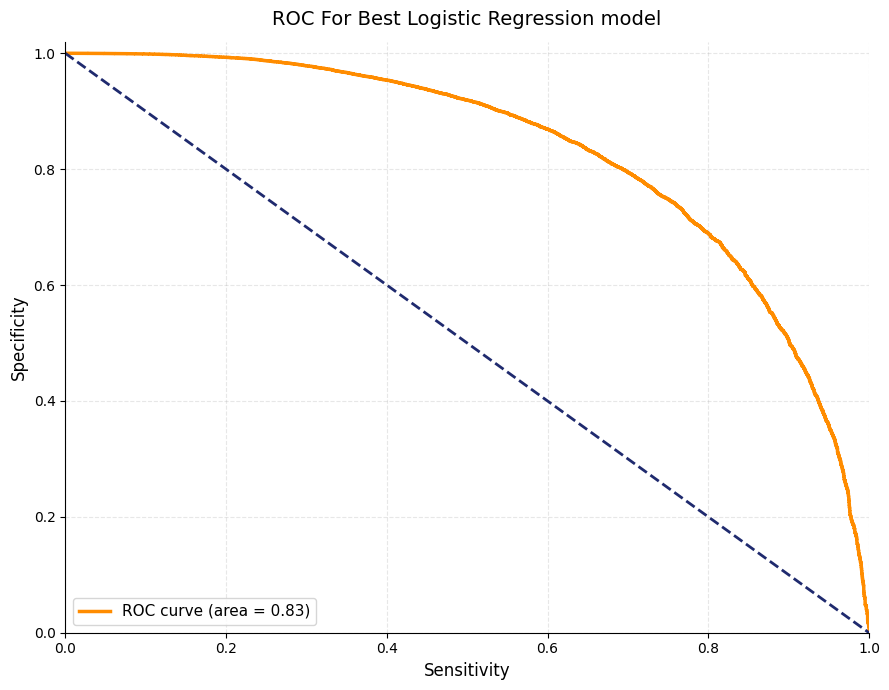

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

test_proba = final_pipeline.predict_proba(X_te_raw)[:, 1]

fpr, tpr, _ = roc_curve(y_te, test_proba)
specificity = 1 - fpr  
sensitivity = tpr      

auc_score = roc_auc_score(y_te, test_proba)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(sensitivity, specificity, color='#FF8C00', linewidth=2.5,
        label=f'ROC curve (area = {auc_score:.2f})')
ax.plot([0, 1], [1, 0], color='#1F2A6E', linestyle='--', linewidth=2)

ax.set_xlabel('Sensitivity', fontsize=12)
ax.set_ylabel('Specificity', fontsize=12)
ax.set_title('ROC For Best Logistic Regression model', fontsize=14, pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower left', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()